# Notebook description
This notebook contains all the general features to set up a model that uses the methods we implemented during our work.

Moreover, it is possible to generate a CSV file containing the predictions of the trained model over the test set, used to submit the results to Kaggle.

The inference algorithm computes the mean class wise softmax probabilities over all the windows derived from the same test sequence and classifies the sample according to the highest mean probability.

---



# Google Drive connection

In [1]:
from google.colab import drive
drive.mount("/gdrive")
current_dir = "/gdrive/My\\ Drive/challengeAN2DL"
%cd $current_dir

Mounted at /gdrive
/gdrive/.shortcut-targets-by-id/1FBs0a25Urpk8cZPLeXuOnI8nzY3Yx1TA/challengeAN2DL


In [2]:
EXPERIMENT_NAME = "general"

# -------------------------
# Early stopping - parameters
# -------------------------
PATIENCE = 50

# -------------------------
# Data loading - parameters
# -------------------------
BATCH_SIZE = 128
EPOCHS = 300

# -------------------------
# Sequence building - parameters
# -------------------------
WINDOW_SIZE = 64
STRIDE = 16

# -------------------------
# Network model - parameters
# -------------------------

# Learning parameters
LEARNING_RATE = 7e-4

# Regularisation parameters
L1_LAMBDA = 0
L2_LAMBDA = 0.001

# -----------RNN-----------
RNN_TYPE = "GRU"
RNN_HIDDEN_SIZE = 64
RNN_HIDDEN_LAYERS = 2
RNN_DROPOUT = 0.4
RNN_BIDIRECTIONAL = True

# -----------CNN-----------
USE_CONVOLUTIONAL_LAYER = False

CONV_OUT_CHANNELS = 512
CONV_KERNEL_SIZE = 3
CONV_STRIDE = 1
CONV_PADDING = None
CONV_DROPOUT = 0.3

# ---------DENSE LAYER-----
USE_DENSE_LAYER = True

DENSE_HIDDEN_SIZE = 64
DENSE_DROPOUT = 0.3

# -------------------------
# Weighted loss - parameters
# -------------------------
USE_WEIGHTED_LOSS = False

# -------------------------
# Adaptive stride - parameters
# -------------------------
USE_ADAPTIVE_STRIDE = True

stride_class_0 = 16
stride_class_1 = 8
stride_class_2 = 4

inference_stride = 8

# -------------------------
# Label Smoothing - parameters
# -------------------------
USE_LABEL_SMOOTHING = False
label_smoothing = 0.05

# -------------------------
# Oversampling - parameters
# -------------------------
USE_OVERSAMPLING = False

# -------------------------
# Gradient clipping - parameters
# -------------------------
USE_GRADIENT_CLIPPING = True
max_norm = 3.0

# -------------------------
# Learning rate scheduler - parameters
# -------------------------
USE_SCHEDULER = False
scheduler_factor = 0.4
scheduler_min_lr = 1e-5
scheduler_patience = max(10, PATIENCE//2)

# -------------------------
# Outlier Drop
# -------------------------
USE_OUTLIER_DROP = True

# -------------------------
# Bagging - produce class probabilities
# -------------------------
SAVE_CLASS_PROBABILITIES = True
file_name = "class_probabilities.npy"

# Import libraries

In [3]:
# Set seed for reproducibility
SEED = 1

# Import necessary libraries
import os

# Set environment variables before importing modules
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['MPLCONFIGDIR'] = os.getcwd() + '/configs/'

# Suppress warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=Warning)

# Import necessary modules
import logging
import random
import numpy as np

# Set seeds for random number generators in NumPy and Python
np.random.seed(SEED)
random.seed(SEED)

# Import PyTorch
import torch
torch.manual_seed(SEED)
from torch import nn
# from torchsummary import summary
from torch.utils.tensorboard import SummaryWriter
from torch.utils.data import TensorDataset, DataLoader
logs_dir = "tensorboard"
!pkill -f tensorboard
%load_ext tensorboard
!mkdir -p models

if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

# Import other libraries
import copy
import shutil
from itertools import product
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configure plot display settings
sns.set(font_scale=1.4)
sns.set_style('white')
plt.rc('font', size=14)
%matplotlib inline

PyTorch version: 2.8.0+cu126
Device: cuda


# Data loading

In [4]:
# DATASET NAMES
DATASET_NAME_TRAINING = "an2dl2526c1/pirate_pain_train.csv"
DATASET_NAME_LABELS = "an2dl2526c1/pirate_pain_train_labels.csv"
DATASET_NAME_TEST = "an2dl2526c1/pirate_pain_test.csv"

df = pd.read_csv(DATASET_NAME_TRAINING)
labels = pd.read_csv(DATASET_NAME_LABELS)
df_test = pd.read_csv(DATASET_NAME_TEST)

# Data preprocessing

In [5]:
# Drop constant features
df = df.drop('joint_30', axis=1)
df_test = df_test.drop('joint_30', axis=1)

# Drop redundant features [n_legs, n_hands, n_eyes]
df = df.drop('n_legs', axis=1)
df_test = df_test.drop('n_legs', axis=1)
df = df.drop('n_hands', axis=1)
df_test = df_test.drop('n_hands', axis=1)
df = df.drop('n_eyes', axis=1)
df_test = df_test.drop('n_eyes', axis=1)

# Transformation to float32
# pain_survey
for index in range(4):
    i = index + 1
    column = 'pain_survey_' + str(i)
    df[column] = df[column].astype(np.float32)
    df_test[column] = df_test[column].astype(np.float32)

# joint
for index in range(30):
    column = 'joint_' + str(index).zfill(2)
    df[column] = df[column].astype(np.float32)
    df_test[column] = df_test[column].astype(np.float32)


In [6]:
# Outlier drop
if USE_OUTLIER_DROP:
  drop_indeces = [16, 21, 137, 152, 225, 357, 381, 418, 439, 444, 511, 513, 521, 566, 628, 657,
                44, 338, 465,
                92, 300]

  df = df[~df["sample_index"].isin(drop_indeces)]
  labels = labels[~labels["sample_index"].isin(drop_indeces)]


In [7]:
# OVERSAMPLING FUNCTION
# this function randomly duplicates entire sequences belonging to the minority classes,
# returning a perfectly balanced dataset.

def oversample_sequences_keep_majority(
    df,
    sample_col='sample_index',
    label_col='pain_level',
    random_state=42
):
    rng = np.random.default_rng(random_state)

    # consistency check: each sequence must have timestamps belonging to the same class
    per_seq_label_nunique = df.groupby(sample_col)[label_col].nunique()
    if (per_seq_label_nunique > 1).any():
        bad = per_seq_label_nunique[per_seq_label_nunique > 1].index.tolist()
        raise ValueError(f"Sequenze con label incoerente: {bad}")

    # labels for each sequence
    seq_labels = df.groupby(sample_col)[label_col].first()

    # class frequency computation
    class_counts = seq_labels.value_counts().sort_index()
    print("Class counts (before oversampling):")
    print(class_counts)
    target_per_class = class_counts.max()
    maj_class = class_counts.idxmax()


    dfs = [df]
    next_sample_index = df[sample_col].max() + 1

    # for each minority class, we duplicate random sequences, until we reach a count of "target_per_class" sequences
    for cls, count in class_counts.items():
        if cls == maj_class:
            continue
        deficit = target_per_class - count
        if deficit <= 0:
            continue
        cls_seq_ids = seq_labels[seq_labels == cls].index.to_numpy()
        chosen_ids = rng.choice(cls_seq_ids, size=deficit, replace=True)
        for orig_id in chosen_ids:
            seq_df = df[df[sample_col] == orig_id].copy()
            seq_df[sample_col] = next_sample_index  # nuovo id
            dfs.append(seq_df)
            next_sample_index += 1

    # new oversampled dataset
    df_over = pd.concat(dfs, ignore_index=True)

    # final frequency check
    new_seq_labels = df_over.groupby(sample_col)[label_col].first()
    new_class_counts = new_seq_labels.value_counts().sort_index()
    print("\nClass counts (after oversampling):")
    print(new_class_counts)

    return df_over

In [8]:
# Splitting

# add labels to train set
df = df.merge(labels, on='sample_index', how='left')
df = df.rename(columns={'label': 'pain_level'})

# Identify single sequences by index
unique_pirates = df['sample_index'].unique()
random.seed(SEED)
random.shuffle(unique_pirates)

# Split
N_TRAIN_PIRATES = int(len(unique_pirates) * 0.8)
N_VAL_PIRATES = len(unique_pirates) - N_TRAIN_PIRATES

train_pirates = unique_pirates[:N_TRAIN_PIRATES]
val_pirates = unique_pirates[N_TRAIN_PIRATES:]

df_train = df[df['sample_index'].isin(train_pirates)]

if USE_OVERSAMPLING:
  df_train = oversample_sequences_keep_majority(df_train,
                                                sample_col='sample_index',
                                                label_col='pain_level',
                                                random_state=SEED)

df_val = df[df['sample_index'].isin(val_pirates)]

if USE_WEIGHTED_LOSS:
    counts = df_train['pain_level'].value_counts().reindex([0,1,2], fill_value=0).to_numpy(np.float32)
    weights = (1 / np.where(counts > 0, counts, 1)) / (1 / np.where(counts > 0, counts, 1)).sum()
    if USE_LABEL_SMOOTHING:
        criterion = nn.CrossEntropyLoss(weight=torch.tensor(weights).to(device), label_smoothing=label_smoothing)
    else:
        criterion = nn.CrossEntropyLoss(weight=torch.tensor(weights).to(device))
else:
    if USE_LABEL_SMOOTHING:
        criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    else:
        criterion = nn.CrossEntropyLoss()

# Print the shapes of the training, validation, and test sets
print(f'Training set shape: {df_train.shape}')
print(f'Validation set shape: {df_val.shape}')
print(f'Test set shape: {df_test.shape}') # test set is unlabeled


Training set shape: (81920, 37)
Validation set shape: (20480, 37)
Test set shape: (211840, 36)


In [9]:
# Check class distribution in training set
training_labels = {
    'no_pain': 0,
    'low_pain': 0,
    'high_pain': 0
}

for id in df_train['sample_index'].unique():
    label = df_train[df_train['sample_index'] == id]['pain_level'].values[0]
    training_labels[label] += 1/N_TRAIN_PIRATES

# Print the distribution of training labels
print('Training labels:', training_labels)

Training labels: {'no_pain': 0.767578125, 'low_pain': 0.142578125, 'high_pain': 0.08984375}


In [10]:
# Check class distribution in validation set
validation_labels = {
    'no_pain': 0,
    'low_pain': 0,
    'high_pain': 0
}

for id in df_val['sample_index'].unique():
    label = df_val[df_val['sample_index'] == id]['pain_level'].values[0]
    validation_labels[label] += 1/N_VAL_PIRATES

# Print the distribution of training labels
print('Validation labels:', validation_labels)

Validation labels: {'no_pain': 0.796875, 'low_pain': 0.140625, 'high_pain': 0.0625}


In [11]:
# LABEL MAPPING

label_mapping = {
    'no_pain': 0,
    'low_pain': 1,
    'high_pain': 2
}

df_train['pain_level'] = df_train['pain_level'].map(label_mapping)
df_val['pain_level'] = df_val['pain_level'].map(label_mapping)


In [12]:
# Feature normalisation

scale_columns = df_train.columns[2:-1].tolist()

# Calculate the minimum and maximum values from the training data only
mins = df_train[scale_columns].min()
maxs = df_train[scale_columns].max()

# Apply normalisation to the specified columns in all datasets
for column in scale_columns:
    # Normalise the training set
    df_train[column] = (df_train[column] - mins[column]) / (maxs[column] - mins[column])

    # Normalise the validation set
    df_val[column] = (df_val[column] - mins[column]) / (maxs[column] - mins[column])

    # Normalise the test set
    df_test[column] = (df_test[column] - mins[column]) / (maxs[column] - mins[column])


# Sequence building

In [13]:
WINDOW_SIZE = 64
STRIDE = 16

In [14]:
# Mapping for adaptive stride
adaptive_stride_mapping = {
    label_mapping['no_pain']:    stride_class_0,
    label_mapping['low_pain']:   stride_class_1,
    label_mapping['high_pain']:  stride_class_2
}

static_stride_mapping = {
    label_mapping['no_pain']:    STRIDE,
    label_mapping['low_pain']:   STRIDE,
    label_mapping['high_pain']:  STRIDE
}

# Define a function to build sequences from the dataset
def build_sequences(df, window=40, use_adaptive_stride=False, validation=False):
    # Initialise lists to store sequences and their corresponding labels
    dataset = []
    labels = []

    # Iterate over unique IDs in the DataFrame
    for id in df['sample_index'].unique():
        # Extract sensor data for the current ID
        temp = df[df['sample_index'] == id][scale_columns].values

        # Retrieve the activity label for the current ID
        label = df[df['sample_index'] == id]['pain_level'].values[0]

        # Calculate padding length to ensure full windows
        padding_len = window - len(temp) % window

        # Create zero padding and concatenate with the data
        padding = np.zeros((padding_len, len(scale_columns)), dtype='float32')
        temp = np.concatenate((temp, padding))

        # Build feature windows and associate them with labels
        idx = 0
        stride_mapping_to_use = adaptive_stride_mapping if use_adaptive_stride else static_stride_mapping
        stride = inference_stride if validation else stride_mapping_to_use[label]

        # Sanity check to ensure the window is divisible by the stride
        assert window % stride == 0

        while idx + window <= len(temp):
          dataset.append(temp[idx:idx + window])
          labels.append(label)
          idx += stride

    # Convert lists to numpy arrays for further processing
    dataset = np.array(dataset)
    labels = np.array(labels)

    return dataset, labels

In [15]:
X_train, y_train = build_sequences(df_train, WINDOW_SIZE, USE_ADAPTIVE_STRIDE, False)
X_val, y_val = build_sequences(df_val, WINDOW_SIZE, USE_ADAPTIVE_STRIDE, True)

In [16]:
# Define the input shape based on the training data
input_shape = X_train.shape[1:]

# Define the number of classes based on the categorical labels
num_classes = len(np.unique(y_train))

In [17]:
# Convert numpy arrays to PyTorch datasets (pairs features with labels)
train_ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
val_ds   = TensorDataset(torch.from_numpy(X_val), torch.from_numpy(y_val))

In [18]:
def make_loader(ds, batch_size, shuffle, drop_last):
    # Determine optimal number of worker processes for data loading
    cpu_cores = os.cpu_count() or 2
    num_workers = max(2, min(4, cpu_cores))

    # Create DataLoader with performance optimizations
    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers,
        pin_memory=True,  # Faster GPU transfer
        pin_memory_device="cuda" if torch.cuda.is_available() else "",
        prefetch_factor=4,  # Load 4 batches ahead
    )

In [19]:
# Create data loaders with different settings for each phase
train_loader = make_loader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_loader   = make_loader(val_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

# Model building

In [20]:
class RecurrentClassifier(nn.Module):
    """
    RNN classifier with (optional) 1d CNN and (optional) final dense layer.
    """

    def __init__(
            self,
            input_size,
            num_classes=3,

            # -------- CNN ---------
            use_conv=False,
            conv_out_channels=64,
            conv_kernel_size=5,
            conv_stride=1,
            conv_padding=None,
            conv_dropout=0.1,
            conv_batch_norm=True,

            # -------- RNN ----------
            rnn_hidden_size=128,
            rnn_num_layers=2,
            rnn_type='GRU',
            rnn_bidirectional=False,
            rnn_dropout_rate=0.2,

            # ----- Dense Layer -----
            use_dense_layer=False,
            dense_hidden_size=64,
            dense_dropout=0.2
    ):
        super().__init__()

        self.use_conv = use_conv

        self.rnn_type = rnn_type
        self.num_layers = rnn_num_layers
        self.hidden_size = rnn_hidden_size
        self.bidirectional = rnn_bidirectional


        # ---------- CNN core ----------
        if self.use_conv:
            if conv_padding is None:
                # "Same-ish" padding for stride=1
                # This keeps seq_len unchanged when stride=1.
                conv_padding = (conv_kernel_size - 1) // 2

            self.conv = nn.Conv1d(
                in_channels=input_size,
                out_channels=conv_out_channels,
                kernel_size=conv_kernel_size,
                stride=conv_stride,
                padding=conv_padding,
                bias=not conv_batch_norm
            )

            self.conv_bn = nn.BatchNorm1d(conv_out_channels) if conv_batch_norm else None
            self.conv_activation = nn.ReLU()
            self.conv_dropout = nn.Dropout(conv_dropout)

            rnn_input_size = conv_out_channels
        else:
            rnn_input_size = input_size

        # ---------- RNN core ----------
        rnn_map = {
            'RNN': nn.RNN,
            'LSTM': nn.LSTM,
            'GRU': nn.GRU
        }

        if rnn_type not in rnn_map:
            raise ValueError("rnn_type must be 'RNN', 'LSTM', or 'GRU'")

        rnn_module = rnn_map[rnn_type]

        # Dropout inside RNN only applies between stacked layers
        rnn_dropout = rnn_dropout_rate if rnn_num_layers > 1 else 0.0

        self.rnn = rnn_module(
            input_size=rnn_input_size,
            hidden_size=rnn_hidden_size,
            num_layers=rnn_num_layers,
            batch_first=True,        # (batch, seq_len, features)
            bidirectional=rnn_bidirectional,
            dropout=rnn_dropout
        )

        rnn_out_dim = rnn_hidden_size * (2 if rnn_bidirectional else 1)

        # ---------- Dense ----------
        self.use_dense_layer = use_dense_layer
        if self.use_dense_layer:
          self.dense = nn.Sequential(
              nn.Linear(rnn_out_dim,
                        dense_hidden_size),
              nn.ReLU(),
              nn.Dropout(dense_dropout)
          )
          classifier_input_size = dense_hidden_size
        else:
          self.dense = nn.Identity()
          classifier_input_size = rnn_out_dim

        # ---------- Classifier ----------

        self.classifier = nn.Linear(classifier_input_size, num_classes)

    def forward(self, x):
        """
        x shape: (batch_size, seq_length, input_size)
        """

        # ----- CNN -----
        if self.use_conv:
            x = x.transpose(1, 2)
            x = self.conv(x)

            if self.conv_bn is not None:
                x = self.conv_bn(x)

            x = self.conv_activation(x)
            x = self.conv_dropout(x)

            x = x.transpose(1, 2)

        # ----- RNN -----
        rnn_out, hidden = self.rnn(x)

        if self.rnn_type == 'LSTM':
            hidden = hidden[0]

        if self.bidirectional:
            hidden = hidden.view(self.num_layers, 2, -1, self.hidden_size)

            hidden_to_next = torch.cat([hidden[-1, 0, :, :], hidden[-1, 1, :, :]], dim=1)
        else:
            hiddden_to_next = hidden[-1]

        # ----- DENSE -----
        if self.use_dense_layer:
          dense_to_classify = self.dense(hidden_to_next)
          logits = self.classifier(dense_to_classify)
        else:
          logits = self.classifier(hidden_to_next)
        return logits


# Model Training

In [21]:
# Initialize best model tracking variables
best_model = None
best_performance = float('-inf')

In [22]:
def train_one_epoch(model, train_loader, criterion, optimizer, scaler, device, l1_lambda=0, l2_lambda=0):
    """
    Perform one complete training epoch through the entire training dataset.

    Args:
        model (nn.Module): The neural network model to train
        train_loader (DataLoader): PyTorch DataLoader containing training data batches
        criterion (nn.Module): Loss function (e.g., CrossEntropyLoss, MSELoss)
        optimizer (torch.optim): Optimization algorithm (e.g., Adam, SGD)
        scaler (GradScaler): PyTorch's gradient scaler for mixed precision training
        device (torch.device): Computing device ('cuda' for GPU, 'cpu' for CPU)
        l1_lambda (float): Lambda for L1 regularization
        l2_lambda (float): Lambda for L2 regularization

    Returns:
        tuple: (average_loss, f1 score) - Training loss and f1 score for this epoch
    """
    model.train()  # Set model to training mode

    running_loss = 0.0
    all_predictions = []
    all_targets = []

    # Iterate through training batches
    for batch_idx, (inputs, targets) in enumerate(train_loader):
        # Move data to device (GPU/CPU)
        inputs, targets = inputs.to(device), targets.to(device)

        # Clear gradients from previous step
        optimizer.zero_grad(set_to_none=True)

        # Forward pass with mixed precision (if CUDA available)
        with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
            logits = model(inputs)
            loss = criterion(logits, targets)

            # Add L1 and L2 regularization
            l1_norm = sum(p.abs().sum() for p in model.parameters())
            l2_norm = sum(p.pow(2).sum() for p in model.parameters())
            loss = loss + l1_lambda * l1_norm + l2_lambda * l2_norm


        # Backward pass with gradient scaling
        scaler.scale(loss).backward()

        # Gradient clipping
        if USE_GRADIENT_CLIPPING:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(),max_norm=max_norm)

        scaler.step(optimizer)
        scaler.update()

        # Accumulate metrics
        running_loss += loss.item() * inputs.size(0)
        predictions = logits.argmax(dim=1)
        all_predictions.append(predictions.cpu().numpy())
        all_targets.append(targets.cpu().numpy())

    # Calculate epoch metrics
    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_f1 = f1_score(
        np.concatenate(all_targets),
        np.concatenate(all_predictions),
        average='weighted'
    )

    return epoch_loss, epoch_f1

In [23]:
def validate_one_epoch(model, val_loader, criterion, device):
    """
    Perform one complete validation epoch through the entire validation dataset.

    Args:
        model (nn.Module): The neural network model to evaluate (must be in eval mode)
        val_loader (DataLoader): PyTorch DataLoader containing validation data batches
        criterion (nn.Module): Loss function used to calculate validation loss
        device (torch.device): Computing device ('cuda' for GPU, 'cpu' for CPU)

    Returns:
        tuple: (average_loss, accuracy) - Validation loss and accuracy for this epoch

    Note:
        This function automatically sets the model to evaluation mode and disables
        gradient computation for efficiency during validation.
    """
    model.eval()  # Set model to evaluation mode

    running_loss = 0.0
    all_predictions = []
    all_targets = []

    # Disable gradient computation for validation
    with torch.no_grad():
        for inputs, targets in val_loader:
            # Move data to device
            inputs, targets = inputs.to(device), targets.to(device)

            # Forward pass with mixed precision (if CUDA available)
            with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                logits = model(inputs)
                loss = criterion(logits, targets)

            # Accumulate metrics
            running_loss += loss.item() * inputs.size(0)
            predictions = logits.argmax(dim=1)
            all_predictions.append(predictions.cpu().numpy())
            all_targets.append(targets.cpu().numpy())

    # Calculate epoch metrics
    epoch_loss = running_loss / len(val_loader.dataset)
    epoch_accuracy = f1_score(
        np.concatenate(all_targets),
        np.concatenate(all_predictions),
        average='weighted'
    )

    return epoch_loss, epoch_accuracy

In [24]:
def log_metrics_to_tensorboard(writer, epoch, train_loss, train_f1, val_loss, val_f1, model):
    """
    Log training metrics and model parameters to TensorBoard for visualization.

    Args:
        writer (SummaryWriter): TensorBoard SummaryWriter object for logging
        epoch (int): Current epoch number (used as x-axis in TensorBoard plots)
        train_loss (float): Training loss for this epoch
        train_f1 (float): Training f1 score for this epoch
        val_loss (float): Validation loss for this epoch
        val_f1 (float): Validation f1 score for this epoch
        model (nn.Module): The neural network model (for logging weights/gradients)

    Note:
        This function logs scalar metrics (loss/f1 score) and histograms of model
        parameters and gradients, which helps monitor training progress and detect
        issues like vanishing/exploding gradients.
    """
    # Log scalar metrics
    writer.add_scalar('Loss/Training', train_loss, epoch)
    writer.add_scalar('Loss/Validation', val_loss, epoch)
    writer.add_scalar('F1/Training', train_f1, epoch)
    writer.add_scalar('F1/Validation', val_f1, epoch)

    # Log model parameters and gradients
    for name, param in model.named_parameters():
        if param.requires_grad:
            # Check if the tensor is not empty before adding a histogram
            if param.numel() > 0:
                writer.add_histogram(f'{name}/weights', param.data, epoch)
            if param.grad is not None:
                # Check if the gradient tensor is not empty before adding a histogram
                if param.grad.numel() > 0:
                    if param.grad is not None and torch.isfinite(param.grad).all():
                        writer.add_histogram(f'{name}/gradients', param.grad.data, epoch)

In [25]:
def fit(model, train_loader, val_loader, epochs, criterion, optimizer, scaler, device,
        l1_lambda=0, l2_lambda=0, patience=0, evaluation_metric="val_f1", mode='max',
        restore_best_weights=True, writer=None, verbose=10, experiment_name="", scheduler=None):
    """
    Train the neural network model on the training data and validate on the validation data.

    Args:
        model (nn.Module): The neural network model to train
        train_loader (DataLoader): PyTorch DataLoader containing training data batches
        val_loader (DataLoader): PyTorch DataLoader containing validation data batches
        epochs (int): Number of training epochs
        criterion (nn.Module): Loss function (e.g., CrossEntropyLoss, MSELoss)
        optimizer (torch.optim): Optimization algorithm (e.g., Adam, SGD)
        scaler (GradScaler): PyTorch's gradient scaler for mixed precision training
        device (torch.device): Computing device ('cuda' for GPU, 'cpu' for CPU)
        l1_lambda (float): L1 regularization coefficient (default: 0)
        l2_lambda (float): L2 regularization coefficient (default: 0)
        patience (int): Number of epochs to wait for improvement before early stopping (default: 0)
        evaluation_metric (str): Metric to monitor for early stopping (default: "val_f1")
        mode (str): 'max' for maximizing the metric, 'min' for minimizing (default: 'max')
        restore_best_weights (bool): Whether to restore model weights from best epoch (default: True)
        writer (SummaryWriter, optional): TensorBoard SummaryWriter object for logging (default: None)
        verbose (int, optional): Frequency of printing training progress (default: 10)
        experiment_name (str, optional): Experiment name for saving models (default: "")

    Returns:
        tuple: (model, training_history) - Trained model and metrics history
    """

    # Initialize metrics tracking
    training_history = {
        'train_loss': [], 'val_loss': [],
        'train_f1': [], 'val_f1': []
    }

    # Configure early stopping if patience is set
    if patience > 0:
        patience_counter = 0
        best_metric = float('-inf') if mode == 'max' else float('inf')
        best_epoch = 0

    print(f"Training {epochs} epochs...")

    # Main training loop: iterate through epochs
    for epoch in range(1, epochs + 1):

        # Forward pass through training data, compute gradients, update weights
        train_loss, train_f1 = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler, device, l1_lambda, l2_lambda
        )

        # Evaluate model on validation data without updating weights
        val_loss, val_f1 = validate_one_epoch(
            model, val_loader, criterion, device
        )

        # Step the scheduler if provided (typically after validation)
        if scheduler is not None:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_f1)
            else:
                scheduler.step()

        # Store metrics for plotting and analysis
        training_history['train_loss'].append(train_loss)
        training_history['val_loss'].append(val_loss)
        training_history['train_f1'].append(train_f1)
        training_history['val_f1'].append(val_f1)

        # Write metrics to TensorBoard for visualization
        if writer is not None:
            log_metrics_to_tensorboard(
                writer, epoch, train_loss, train_f1, val_loss, val_f1, model
            )

        # Print progress every N epochs or on first epoch
        if verbose > 0:
            if epoch % verbose == 0 or epoch == 1:
                print(f"Epoch {epoch:3d}/{epochs} | "
                    f"Train: Loss={train_loss:.4f}, F1 Score={train_f1:.4f} | "
                    f"Val: Loss={val_loss:.4f}, F1 Score={val_f1:.4f}")

        # Early stopping logic: monitor metric and save best model
        if patience > 0:
            current_metric = training_history[evaluation_metric][-1]
            is_improvement = (current_metric > best_metric) if mode == 'max' else (current_metric < best_metric)

            if is_improvement:
                best_metric = current_metric
                best_epoch = epoch
                torch.save(model.state_dict(), "models/"+experiment_name+'_model.pt')
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"Early stopping triggered after {epoch} epochs.")
                    break

    # Restore best model weights if early stopping was used
    if restore_best_weights and patience > 0:
        model.load_state_dict(torch.load("models/"+experiment_name+'_model.pt'))
        print(f"Best model restored from epoch {best_epoch} with {evaluation_metric} {best_metric:.4f}")

    # Save final model if no early stopping
    if patience == 0:
        torch.save(model.state_dict(), "models/"+experiment_name+'_model.pt')

    # Close TensorBoard writer
    if writer is not None:
        writer.close()

    return model, training_history

# Training

In [26]:
# Create model and display architecture with parameter count

rnn_model = RecurrentClassifier(
    input_size = input_shape[-1],
    num_classes = 3,
    use_conv = USE_CONVOLUTIONAL_LAYER,
    conv_out_channels = CONV_OUT_CHANNELS,
    conv_kernel_size = CONV_KERNEL_SIZE,
    conv_stride = CONV_STRIDE,
    conv_padding = CONV_PADDING,
    conv_dropout = CONV_DROPOUT,
    conv_batch_norm = True,
    rnn_hidden_size = RNN_HIDDEN_SIZE,
    rnn_num_layers = RNN_HIDDEN_LAYERS,
    rnn_type = RNN_TYPE,
    rnn_dropout_rate=RNN_DROPOUT,
    rnn_bidirectional=RNN_BIDIRECTIONAL,
    use_dense_layer = USE_DENSE_LAYER,
    dense_hidden_size = DENSE_HIDDEN_SIZE,
    dense_dropout = DENSE_DROPOUT,
).to(device)

# Set up TensorBoard logging and save model architecture
experiment_name = EXPERIMENT_NAME
writer = SummaryWriter("./"+logs_dir+"/"+experiment_name)
x = torch.randn(1, input_shape[0], input_shape[1]).to(device)
writer.add_graph(rnn_model, x)

# Define optimizer with L2 regularization
optimizer = torch.optim.AdamW(rnn_model.parameters(), lr=LEARNING_RATE, weight_decay=L2_LAMBDA)

# Enable mixed precision training for GPU acceleration
scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))

In [27]:
# Scheduler declaration
if USE_SCHEDULER:
  scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',                  # Monitor a metric that should be maximized (validation f1)
    factor=scheduler_factor,     # Factor by which the learning rate will be reduced
    patience=scheduler_patience, # Number of epochs with no improvement after which learning rate will be reduced
    min_lr= scheduler_min_lr     # Minimum learning rate
  )
else:
  scheduler = None

In [28]:
%%time
# Train model and track training history
rnn_model, training_history = fit(
    model=rnn_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    criterion=criterion,
    optimizer=optimizer,
    scaler=scaler,
    device=device,
    writer=writer,
    verbose=1,
    experiment_name=experiment_name,
    patience=PATIENCE,
    scheduler=scheduler
    )

# Update best model if current performance is superior
if training_history['val_f1'][-1] > best_performance:
    best_model = rnn_model
    best_performance = training_history['val_f1'][-1]

Training 300 epochs...
Epoch   1/300 | Train: Loss=1.0009, F1 Score=0.4093 | Val: Loss=0.7683, F1 Score=0.7068
Epoch   2/300 | Train: Loss=0.9136, F1 Score=0.5031 | Val: Loss=0.6327, F1 Score=0.7598
Epoch   3/300 | Train: Loss=0.8179, F1 Score=0.5957 | Val: Loss=0.5939, F1 Score=0.7693
Epoch   4/300 | Train: Loss=0.7891, F1 Score=0.6269 | Val: Loss=0.5509, F1 Score=0.7917
Epoch   5/300 | Train: Loss=0.7258, F1 Score=0.6696 | Val: Loss=0.5759, F1 Score=0.7927
Epoch   6/300 | Train: Loss=0.5817, F1 Score=0.7740 | Val: Loss=0.3843, F1 Score=0.8603
Epoch   7/300 | Train: Loss=0.5142, F1 Score=0.8078 | Val: Loss=0.4632, F1 Score=0.8551
Epoch   8/300 | Train: Loss=0.4901, F1 Score=0.8140 | Val: Loss=0.3250, F1 Score=0.9001
Epoch   9/300 | Train: Loss=0.4329, F1 Score=0.8390 | Val: Loss=0.4249, F1 Score=0.8577
Epoch  10/300 | Train: Loss=0.3925, F1 Score=0.8546 | Val: Loss=0.3091, F1 Score=0.8927
Epoch  11/300 | Train: Loss=0.3615, F1 Score=0.8659 | Val: Loss=0.3352, F1 Score=0.8906
Epoch  12

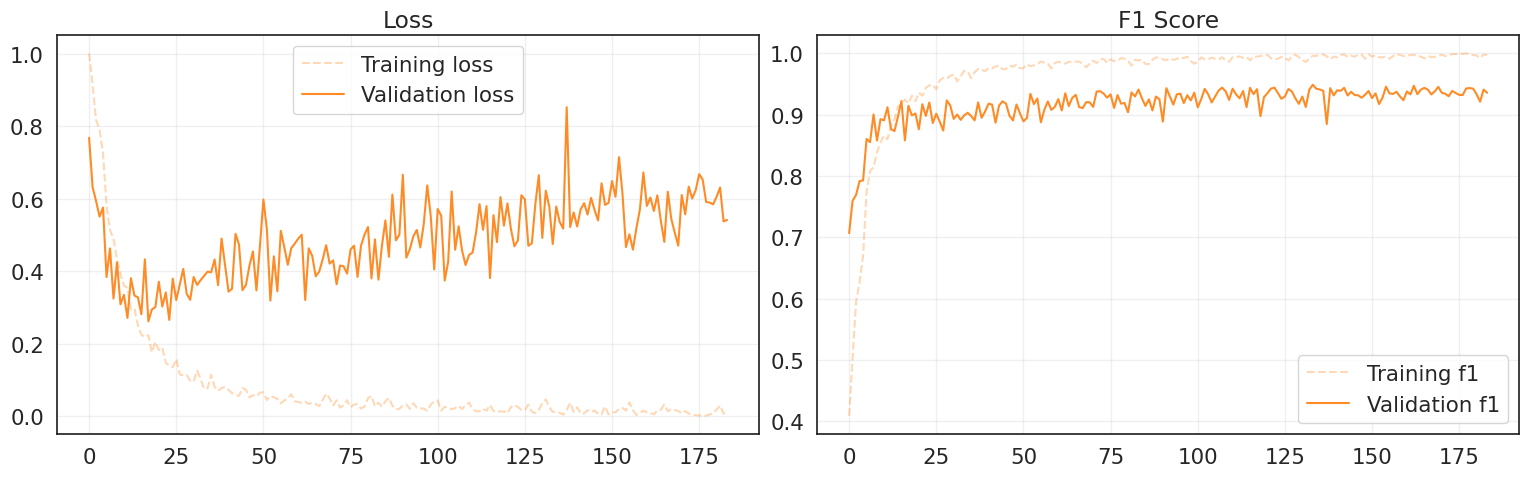

In [29]:
# @title Plot History
# Create a figure with two side-by-side subplots (two columns)
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))

# Plot of training and validation loss on the first axis
ax1.plot(training_history['train_loss'], label='Training loss', alpha=0.3, color='#ff7f0e', linestyle='--')
ax1.plot(training_history['val_loss'], label='Validation loss', alpha=0.9, color='#ff7f0e')
ax1.set_title('Loss')
ax1.legend()
ax1.grid(alpha=0.3)

# Plot of training and validation accuracy on the second axis
ax2.plot(training_history['train_f1'], label='Training f1', alpha=0.3, color='#ff7f0e', linestyle='--')
ax2.plot(training_history['val_f1'], label='Validation f1', alpha=0.9, color='#ff7f0e')
ax2.set_title('F1 Score')
ax2.legend()
ax2.grid(alpha=0.3)

# Adjust the layout and display the plot
plt.tight_layout()
plt.subplots_adjust(right=0.85)
plt.show()

Accuracy over the validation set: 0.9494
Precision over the validation set: 0.9522
Recall over the validation set: 0.9494
F1 score over the validation set: 0.9487


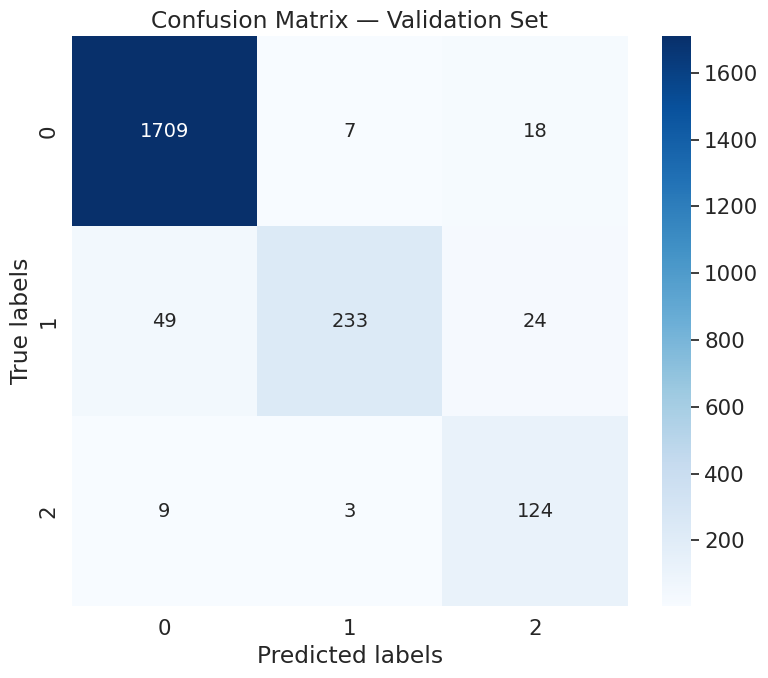

In [30]:
# @title Plot Confusion Matrix
# Collect predictions and ground truth labels
val_preds, val_targets = [], []
with torch.no_grad():  # Disable gradient computation for inference
    for xb, yb in val_loader:
        xb = xb.to(device)

        # Forward pass: get model predictions
        logits = rnn_model(xb)
        preds = logits.argmax(dim=1).cpu().numpy()

        # Store batch results
        val_preds.append(preds)
        val_targets.append(yb.numpy())

# Combine all batches into single arrays
val_preds = np.concatenate(val_preds)
val_targets = np.concatenate(val_targets)

# Calculate overall validation metrics
val_acc = accuracy_score(val_targets, val_preds)
val_prec = precision_score(val_targets, val_preds, average='weighted')
val_rec = recall_score(val_targets, val_preds, average='weighted')
val_f1 = f1_score(val_targets, val_preds, average='weighted')
print(f"Accuracy over the validation set: {val_acc:.4f}")
print(f"Precision over the validation set: {val_prec:.4f}")
print(f"Recall over the validation set: {val_rec:.4f}")
print(f"F1 score over the validation set: {val_f1:.4f}")

# Generate confusion matrix for detailed error analysis
cm = confusion_matrix(val_targets, val_preds)

# Create numeric labels for heatmap annotation
labels = np.array([f"{num}" for num in cm.flatten()]).reshape(cm.shape)

# Visualise confusion matrix
plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=labels, fmt='',
            cmap='Blues')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix — Validation Set')
plt.tight_layout()
plt.show()

# Inference

In [31]:
# Define a function to build sequences from the dataset
def inference(model, df, device):

    # Create a list to store predictions
    predictions = []

    if SAVE_CLASS_PROBABILITIES:
        # Create a list to store softmax class probabilities
        probability_matrix = []

    # Iterate over unique IDs in the DataFrame
    for id in df['sample_index'].unique():
        print("Predicting sequence ", id) if id % 100 == 0 else None
        # Extract data for the current ID
        temp = df[df['sample_index'] == id][scale_columns].values

        # Calculate padding length to ensure full windows
        padding_len = WINDOW_SIZE - len(temp) % WINDOW_SIZE

        # Create zero padding and concatenate with the data
        padding = np.zeros((padding_len, len(scale_columns)), dtype='float32')
        temp = np.concatenate((temp, padding))

        # Create a dataset to contain windows of the current sequence
        seq_windows = []

        # Build feature windows
        idx = 0
        while idx + WINDOW_SIZE <= len(temp):
            seq_windows.append(temp[idx:idx + WINDOW_SIZE])
            idx += STRIDE

        # Convert in a 3x3 matrix (number of windows, window size, number of features)
        seq_windows = np.array(seq_windows)

        # Create TensorDatas
        test_ds = TensorDataset(torch.from_numpy(seq_windows))
        test_loader = make_loader(test_ds, seq_windows.shape[0], shuffle=False, drop_last=False)

        # Perform inference on each window, then average to obtain the prediction
        # for the overall current sequence

        model.eval()
        all_probs = []

        with torch.no_grad():
            for inputs in test_loader:
                inputs = inputs[0].to(device)

                # Forward pass with mixed precision (if CUDA available)
                with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                    logits = model(inputs)           # [B, num_classes]
                    probs = torch.softmax(logits, dim=1)

                all_probs.append(probs.cpu().numpy())

        all_probs = np.concatenate(all_probs, axis=0)   # [N, num_classes]

        # Aggregate across windows
        mean_probs = all_probs.mean(axis=0)            # [num_classes]
        seq_label = mean_probs.argmax()                # final predicted class

        # Store prediction and class probabilities
        predictions.append(seq_label)
        if SAVE_CLASS_PROBABILITIES:
          probability_matrix.append(mean_probs)

    if SAVE_CLASS_PROBABILITIES:
        probabilities = np.array(probability_matrix)  # [n_sequences, num_classes]
        print(probabilities.shape)
        np.save(file_name, probabilities)

    print("Inference process completed")

    return predictions


In [32]:
# Perform inference
predictions = inference(best_model, df_test, device)

Predicting sequence  0
Predicting sequence  100
Predicting sequence  200
Predicting sequence  300
Predicting sequence  400
Predicting sequence  500
Predicting sequence  600
Predicting sequence  700
Predicting sequence  800
Predicting sequence  900
Predicting sequence  1000
Predicting sequence  1100
Predicting sequence  1200
Predicting sequence  1300
(1324, 3)
Inference process completed


# Generate CSV with predictions

In [33]:

# Class mapping
label_map = {
    0: "no_pain",
    1: "low_pain",
    2: "high_pain"
}

# Create a dataframe to generate the csv
pred_df = pd.DataFrame({
    "sample_index": range(len(predictions)),
    "label": [label_map[int(x)] for x in predictions]
})

# Save the csv containing predictions
pred_df.to_csv("submission_general.csv", index=False)
